# Finetuning

This tutorial illustrates how to fine-tune the `GR00T-N1` pretrained checkpoint on a post-training 
dataset using the same embodiment. This showcases the benefit of post-training, transforming a generalist model into a specialist and demonstrating a performance gain.

For this tutorial, we will use the demo dataset `robot_sim.PickNPlace` from the [demo_data](./demo_data) folder. 

We will first load the pre-trained model and evaluate it on the dataset. Then we will finetune the model on the dataset and evaluate the performance.


本教程说明了如何使用相同的实施方案，在训练后数据集上对 GR00T-N1 预训练检查点进行微调。这展示了后训练的好处，将通用模型转变为专业模型，并证明了性能的提高。

在本教程中，我们将使用 demo_data 文件夹中的演示数据集 robot_sim.PickNPlace。

我们将首先加载预训练模型，并在数据集上对其进行评估。然后，我们将在数据集上对模型进行微调，并评估其性能。

## Pre-trained Model

In [1]:
from gr00t.utils.eval import calc_mse_for_single_trajectory
import warnings
from gr00t.experiment.data_config import DATA_CONFIG_MAP
from gr00t.model.policy import Gr00tPolicy
from gr00t.data.schema import EmbodimentTag
from gr00t.data.dataset import LeRobotSingleDataset
import numpy as np
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

warnings.simplefilter("ignore", category=FutureWarning)

/root/anaconda3/envs/gr00t/lib/python3.10/site-packages/albumentations/check_version.py:49: UserWarning: Error fetching version info The read operation timed out
  data = fetch_version_info()
2025-04-30 03:31:22.713075: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 03:31:22.748422: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-30 03:31:22.748447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-30 03:31:22.749298: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] 

Model not found or avail in the huggingface hub. Loading from local path: /root/data/projects/embodiedai/grootn1/GR00T-N1-2B
Loading pretrained dual brain from /root/data/projects/embodiedai/grootn1/GR00T-N1-2B
Tune backbone vision tower: True
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: True
Model not found or avail in the huggingface hub. Loading from local path: /root/data/projects/embodiedai/grootn1/GR00T-N1-2B
Total number of DiT parameters:  537803776
Tune action head projector: True
Tune action head diffusion model: True


Some weights of the model checkpoint at /root/data/projects/embodiedai/grootn1/GR00T-N1-2B were not used when initializing GR00T_N1: ['action_head.decode_layer.bias', 'action_head.decode_layer.weight']
- This IS expected if you are initializing GR00T_N1 from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GR00T_N1 from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Tune action head projector: True
Tune action head diffusion model: True
Initialized dataset robot_sim.PickNPlace with EmbodimentTag.GR1
inferencing at step:  0


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


inferencing at step:  16
inferencing at step:  32
inferencing at step:  48
inferencing at step:  64
inferencing at step:  80
inferencing at step:  96
inferencing at step:  112
inferencing at step:  128
inferencing at step:  144
Unnormalized Action MSE across single traj: 0.2412135476930025


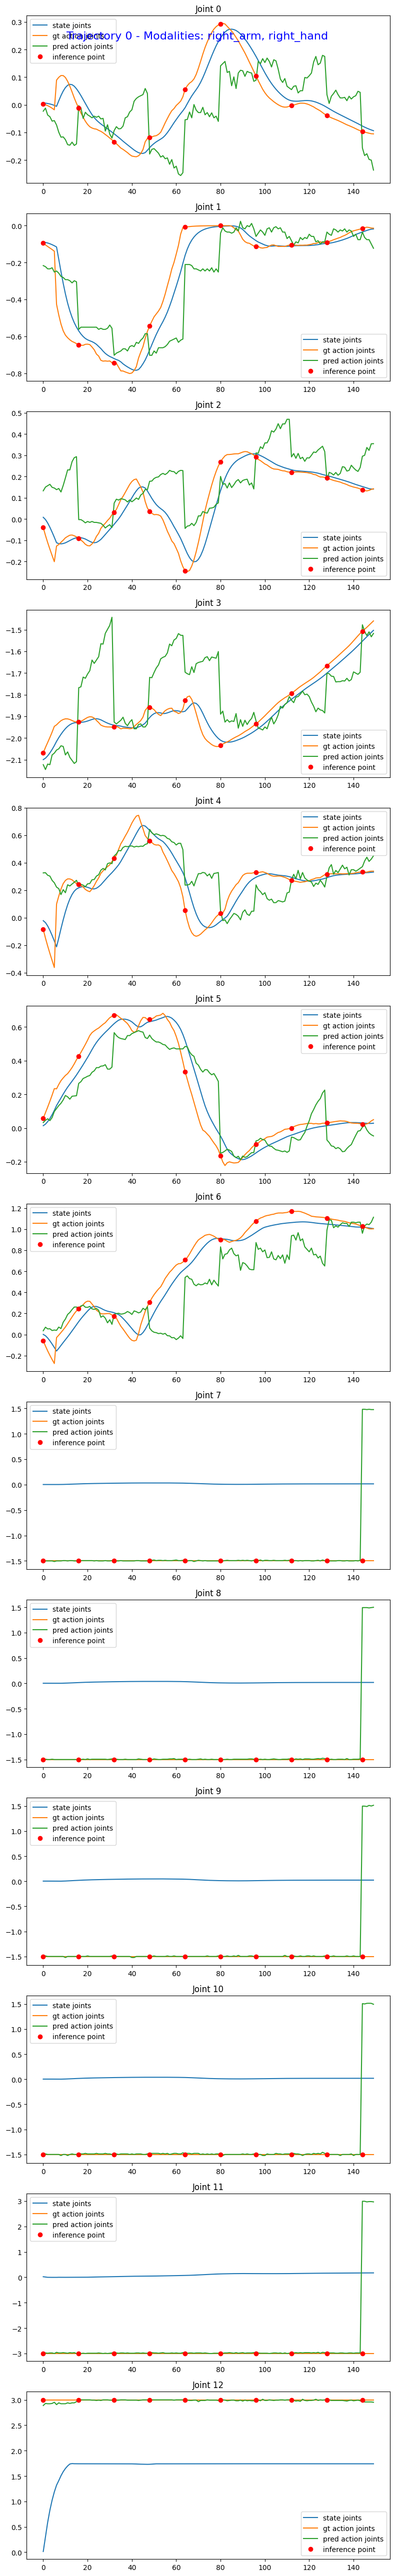

MSE loss for trajectory 0: 0.2412135476930025


In [4]:
PRE_TRAINED_MODEL_PATH = "/root/data/projects/embodiedai/grootn1/GR00T-N1-2B"
EMBODIMENT_TAG = EmbodimentTag.GR1
DATASET_PATH = "/root/data/projects/embodiedai/grootn1/Isaac-GR00T/demo_data/robot_sim.PickNPlace"


data_config = DATA_CONFIG_MAP["gr1_arms_only"]
modality_config = data_config.modality_config()
modality_transform = data_config.transform()


pre_trained_policy = Gr00tPolicy(
    model_path=PRE_TRAINED_MODEL_PATH,
    embodiment_tag=EMBODIMENT_TAG,
    modality_config=modality_config,
    modality_transform=modality_transform,
    device=device,
)

dataset = LeRobotSingleDataset(
    dataset_path=DATASET_PATH,
    modality_configs=modality_config,
    video_backend="decord",
    video_backend_kwargs=None,
    transforms=None,  # We'll handle transforms separately through the policy
    embodiment_tag=EMBODIMENT_TAG,
)


mse = calc_mse_for_single_trajectory(
    pre_trained_policy,
    dataset,
    traj_id=0,
    modality_keys=["right_arm", "right_hand"],   # we will only evaluate the right arm and right hand
    steps=150,
    action_horizon=16,
    plot=True
)

print("MSE loss for trajectory 0:", mse)

Great! we can see the predicted actions and the ground truth actions. The predicted actions are not perfect but they are close to the ground truth actions. That's show that the pretrained checkpoint is working well.

Now let's sample 10 random trajectories and calcuate the mean MSE to get a sense of more verbose results.


很好！我们可以看到预测行动和地面实况行动。预测的行动并不完美，但与地面实况行动很接近。这表明预训练的检查点运行良好。

现在，让我们对 10 个随机轨迹进行采样，计算平均 MSE，以获得更详细的结果

In [5]:
total_trajectories = len(dataset.trajectory_lengths)

print("Total trajectories:", total_trajectories)

sampled_trajectories = np.random.choice(total_trajectories, 10)
print("Sampled trajectories:", sampled_trajectories)

all_mses = []

for traj_id in sampled_trajectories:
    mse = calc_mse_for_single_trajectory(
        pre_trained_policy,
        dataset,
        traj_id=traj_id,
        modality_keys=["right_arm", "right_hand"],   # we will only evaluate the right arm and right hand
        steps=150,
        action_horizon=16,
        plot=False
    )
    print(f"Trajectory {traj_id} MSE: {mse:.4f}")
    
    all_mses.append(mse)

print("====================================")
print("Mean MSE:", np.mean(all_mses))
print("Std MSE:", np.std(all_mses))


Total trajectories: 5
Sampled trajectories: [4 1 3 0 4 0 1 4 0 1]
inferencing at step:  0
inferencing at step:  16
inferencing at step:  32
inferencing at step:  48
inferencing at step:  64
inferencing at step:  80
inferencing at step:  96
inferencing at step:  112
inferencing at step:  128
inferencing at step:  144
Unnormalized Action MSE across single traj: 1.3711792721946563
Trajectory 4 MSE: 1.3712
inferencing at step:  0
inferencing at step:  16
inferencing at step:  32
inferencing at step:  48
inferencing at step:  64
inferencing at step:  80
inferencing at step:  96
inferencing at step:  112
inferencing at step:  128
inferencing at step:  144
Unnormalized Action MSE across single traj: 0.05181051630411067
Trajectory 1 MSE: 0.0518
inferencing at step:  0
inferencing at step:  16
inferencing at step:  32
inferencing at step:  48
inferencing at step:  64
inferencing at step:  80
inferencing at step:  96
inferencing at step:  112
inferencing at step:  128
inferencing at step:  144
U

## Finetuning the Model

Now we will finetune the model on the dataset. Without going into the details of the finetuning process, we will use the `gr00t_finetune.py` script to finetune the model. You can run the following command to finetune the model. 

现在我们将在数据集上对模型进行微调。在不详细介绍微调过程的前提下，我们将使用 gr00t_finetune.py 脚本对模型进行微调。您可以运行以下命令对模型进行微调

```bash
python scripts/gr00t_finetune.py --dataset-path /root/data/projects/embodiedai/grootn1/Isaac-GR00T/demo_data/robot_sim.PickNPlace --num-gpus 1 --max-steps 500 --output-dir /root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/output/get_started_finetuned-model --data-config gr1_arms_only --base-model-path /root/data/projects/embodiedai/grootn1/GR00T-N1-2B
```



_To get a full list of the available arguments, you can run `python scripts/gr00t_finetune.py --help`._

The script will save the finetuned model in the `/tmp/gr00t-1/finetuned-model` directory. We will load the finetuned model with `500` checkpoint steps.  


要获得可用参数的完整列表，可以运行 python scripts/gr00t_finetune.py --help 命令。

脚本会将微调后的模型保存在 /tmp/gr00t-1/finetuned-model 目录中。我们将加载包含 500 个检查点步骤的微调模型

### Evaluation of the Fine-tuned Model

Now we can evaluate the fine-tuned model by running the policy on the dataset and see how well it performs. We will use a utility function to evaluate the policy on the dataset. This is similar to the previous tutorial in [1_pretrained_model.ipynb](1_pretrained_model.ipynb)

现在，我们可以通过在数据集上运行策略来评估微调模型，看看它的性能如何。我们将使用效用函数来评估数据集上的策略。这与之前在 1_pretrained_model.ipynb 中的教程类似

Model not found or avail in the huggingface hub. Loading from local path: /root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/output/get_started_finetuned-model/checkpoint-500
Loading pretrained dual brain from /root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/output/get_started_finetuned-model/checkpoint-500
Tune backbone vision tower: True
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: True
Model not found or avail in the huggingface hub. Loading from local path: /root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/output/get_started_finetuned-model/checkpoint-500
Total number of DiT parameters:  537803776
Tune action head projector: True
Tune action head diffusion model: True


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Tune action head projector: True
Tune action head diffusion model: True
inferencing at step:  0
inferencing at step:  16
inferencing at step:  32
inferencing at step:  48
inferencing at step:  64
inferencing at step:  80
inferencing at step:  96
inferencing at step:  112
inferencing at step:  128
inferencing at step:  144
Unnormalized Action MSE across single traj: 0.004164496093300013


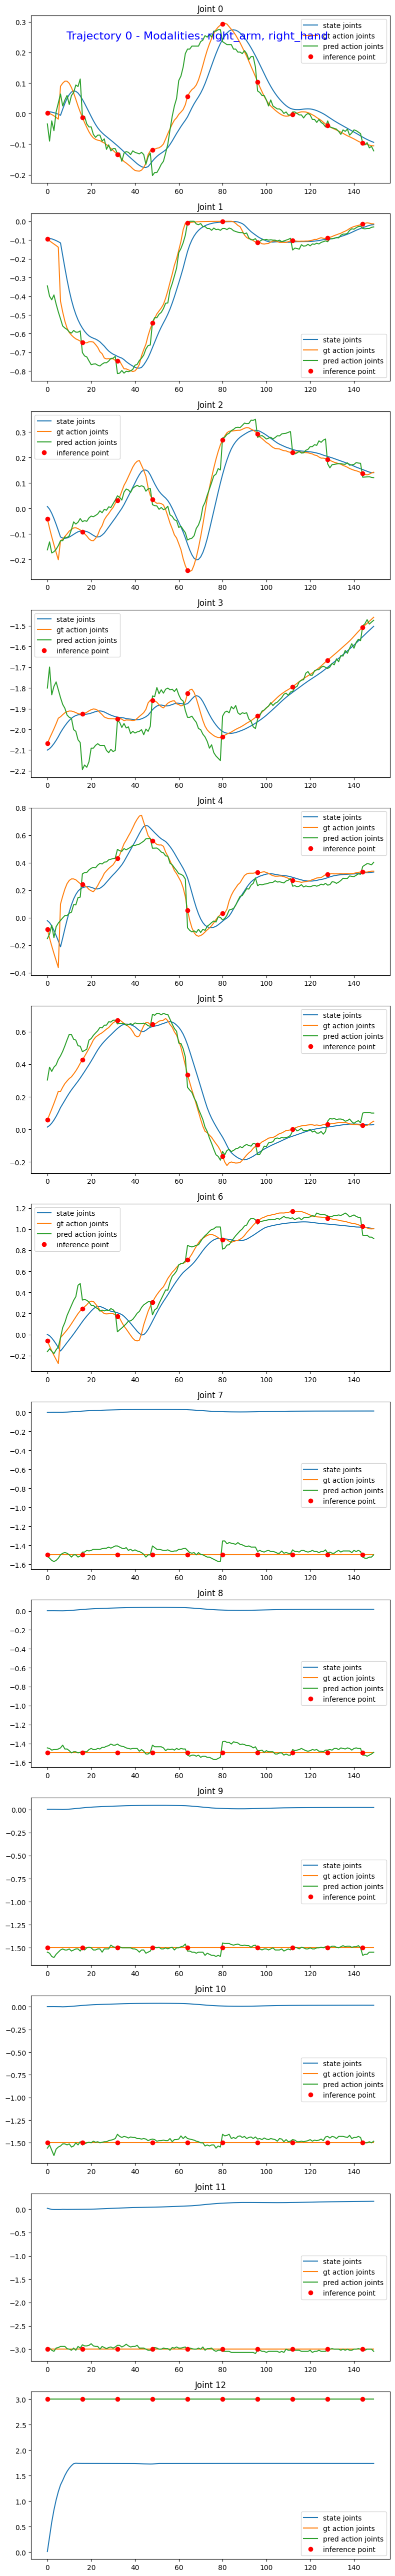

MSE loss for trajectory 0: 0.004164496093300013


In [6]:
from gr00t.utils.eval import calc_mse_for_single_trajectory
import warnings

finetuned_model_path = "/root/data/projects/embodiedai/grootn1/Isaac-GR00T/Isaac-GR00T-injector/output/get_started_finetuned-model/checkpoint-500"
finetuned_policy = Gr00tPolicy(
    model_path=finetuned_model_path,
    embodiment_tag="new_embodiment",
    modality_config=modality_config,
    modality_transform=modality_transform,
    device=device,
)

warnings.simplefilter("ignore", category=FutureWarning)

mse = calc_mse_for_single_trajectory(
    finetuned_policy,
    dataset,
    traj_id=0,
    modality_keys=["right_arm", "right_hand"],   # we will only evaluate the right arm and right hand
    steps=150,
    action_horizon=16,
    plot=True
)

print("MSE loss for trajectory 0:", mse)

Yaay! We have finetuned the model and evaluated it on the dataset. We can see that the model has learned the task and is able to perform the task better than the pre-trained model.

耶！我们对模型进行了微调，并在数据集上对其进行了评估。我们可以看到，模型已经学会了这项任务，并且比预先训练好的模型能更好地完成任务